# Homework 1

## Create pair plot (flash dataset)

<Figure size 640x480 with 0 Axes>

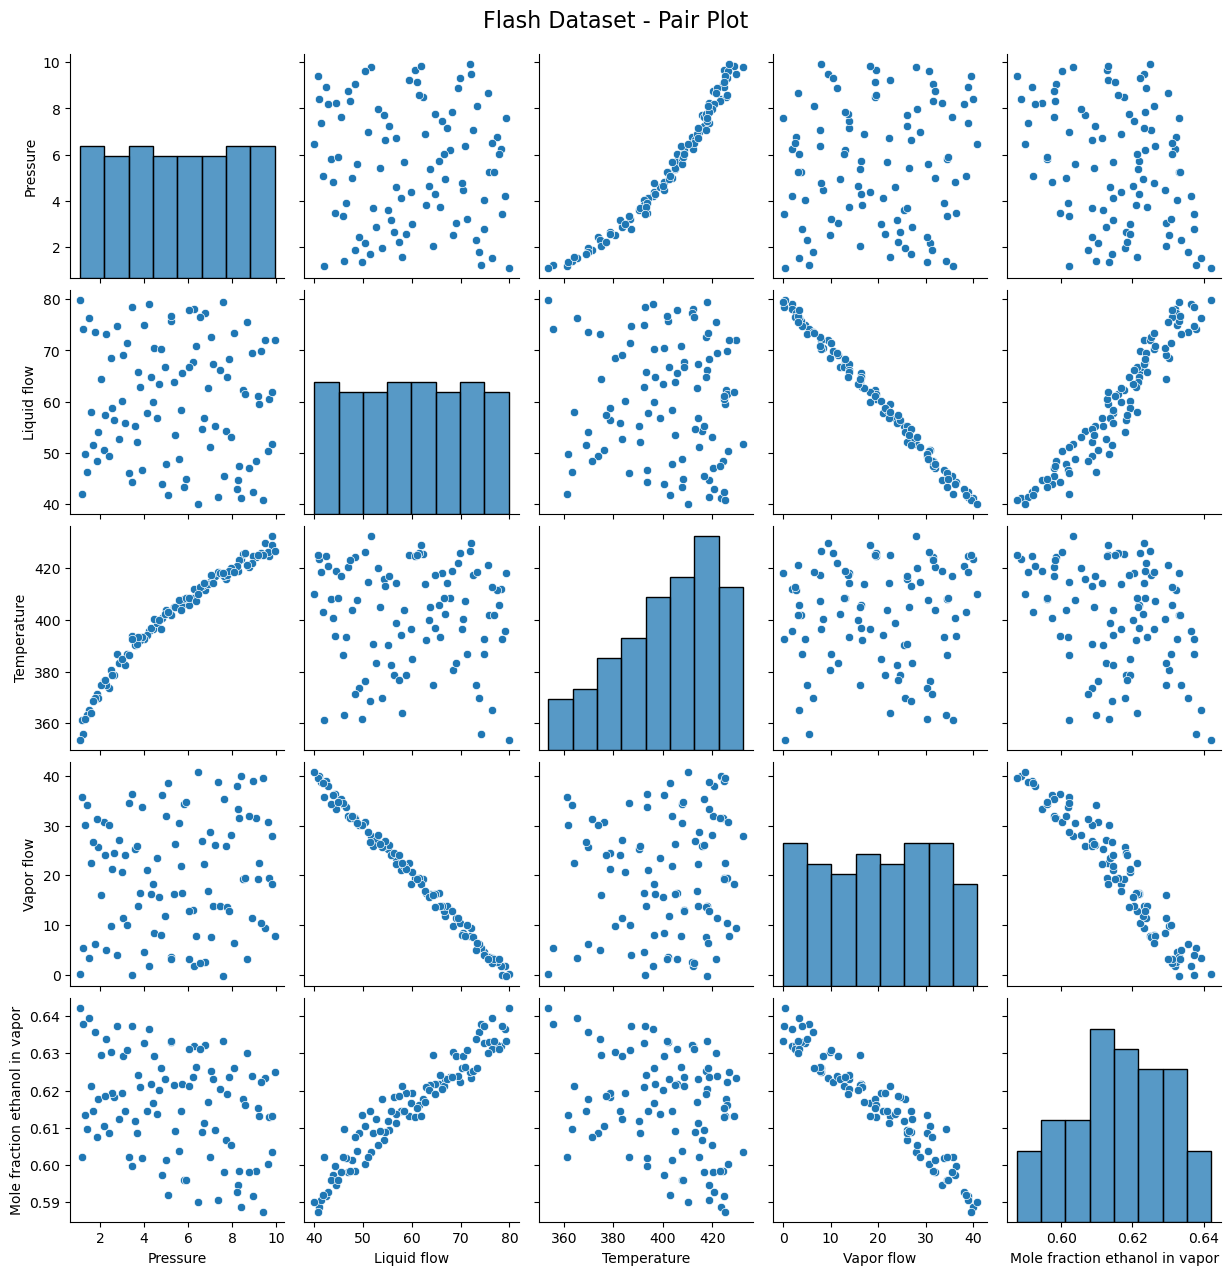

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# read the flash data
df_flash = pd.read_excel("./data_flash.xlsx")

# the first row of the flash data contains text units, drop the first row so we only have the actual numbers left
df_flash = df_flash.drop(0)

# reset the row numbers so they start cleanly from 0 again
df_flash = df_flash.reset_index(drop=True)

# convert all the remaining text-numbers into actual mathematical numbers
df_flash = df_flash.apply(pd.to_numeric)

# this automatically makes a grid of scatter plots for every pair of columns
plt.figure()
flash_pair = sns.pairplot(df_flash)
flash_pair.fig.suptitle("Flash Dataset - Pair Plot", y=1.02, fontsize=16)

# save the resulting plot as an image
plt.savefig("flash_pairplot.png", bbox_inches='tight')
plt.show()
plt.close('all') # Clear plot memory

### Pair Plot Observations (flash dataset)

The pair plot for the flash dataset shows the distributions and pairwise relationships between the continuous thermodynamic variables.
- From the diagonal histograms we can see that most thermodynamic variables do not follow a perfect-bell shaped normal distribution, but instead they tend to be uniformly distributed or skewed across a specific operational range. This is usual for parameter sweeps, it indicates operation across a wide window to map out the system's behavior, rather than being held at a single steady-state setpoint.
- There seem to not be any severe outliers, the scatter plots generally show tight continuous curves or point clouds. Low amount of outliers could be due to good sensor calibration and high process stability.
- There are no distinct separate clusters.

## Create correlation matrix (flash dataset) 

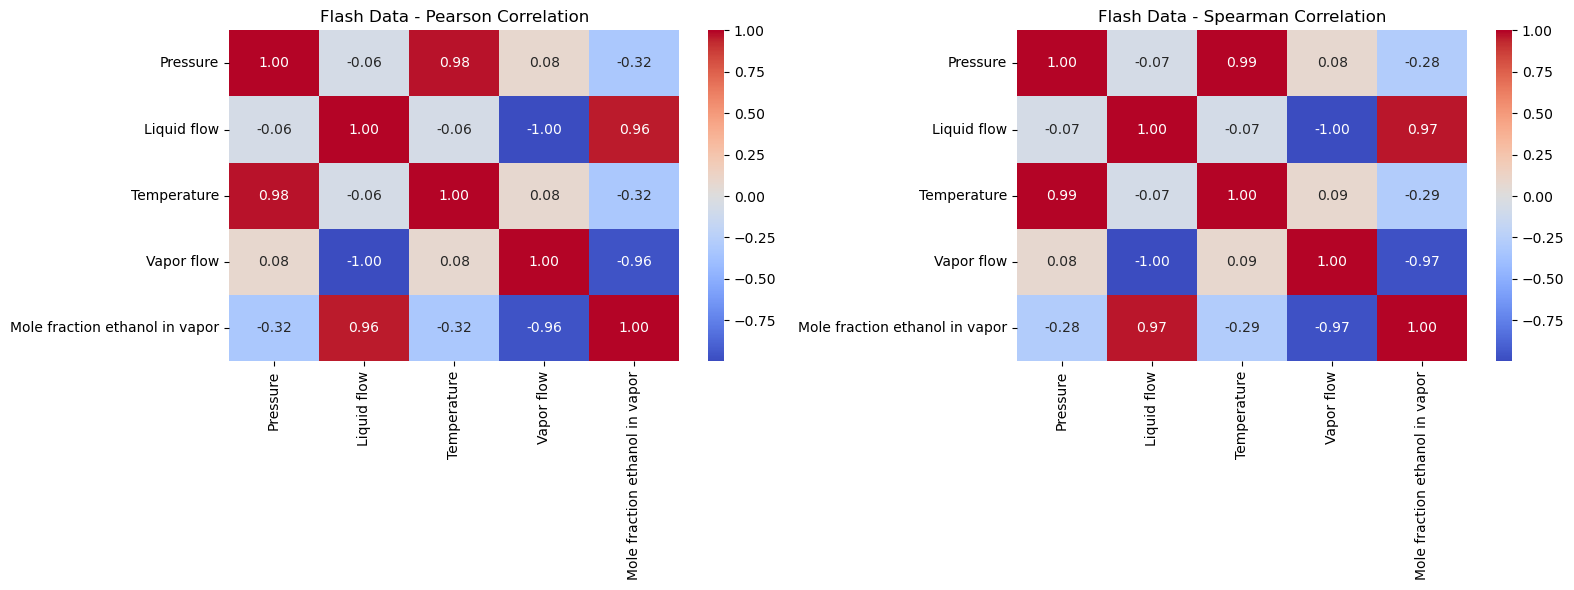

In [13]:
# calculate the pearson and spearman correlation numbers
corr_flash_pearson = df_flash.corr(method='pearson')
corr_flash_spearman = df_flash.corr(method='spearman')

# create a blank image with 1 row and 2 columns for our side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# draw pearson heatmap on the left side
# need to put annot=True so correlation numbers ar inside the colored boxes
sns.heatmap(corr_flash_pearson, annot=True, cmap='coolwarm', ax=axes[0], fmt=".2f")
axes[0].set_title('Flash Data - Pearson Correlation')

# draw spearman heatmap on the right side
sns.heatmap(corr_flash_spearman, annot=True, cmap='coolwarm', ax=axes[1], fmt=".2f")
axes[1].set_title('Flash Data - Spearman Correlation')

# adjust layout and save as image
plt.tight_layout()
plt.savefig("flash_heatmaps.png")
plt.show()
plt.close('all') # Clear memory again

### Correlation Matrix Observations (flash dataset)

Strong positive correlations:
- Pressure and Temperature
- Liquid flow and mole fraction

Strong negative correlations:
- Liquid flow and vapor flow
- Vapor flow and mole fraction

The Relationships follow thermodynamic curves. These curves are not straight lines, thus the Spearman correlations for these pairs are often slightly higher than the Pearson counterparts, since the Spearman coefficient is better for measuring relationships where variables consistently move together along a curve rather than a perfectly straight line. 

## Create pair plot (manufacturing dataset)

<Figure size 640x480 with 0 Axes>

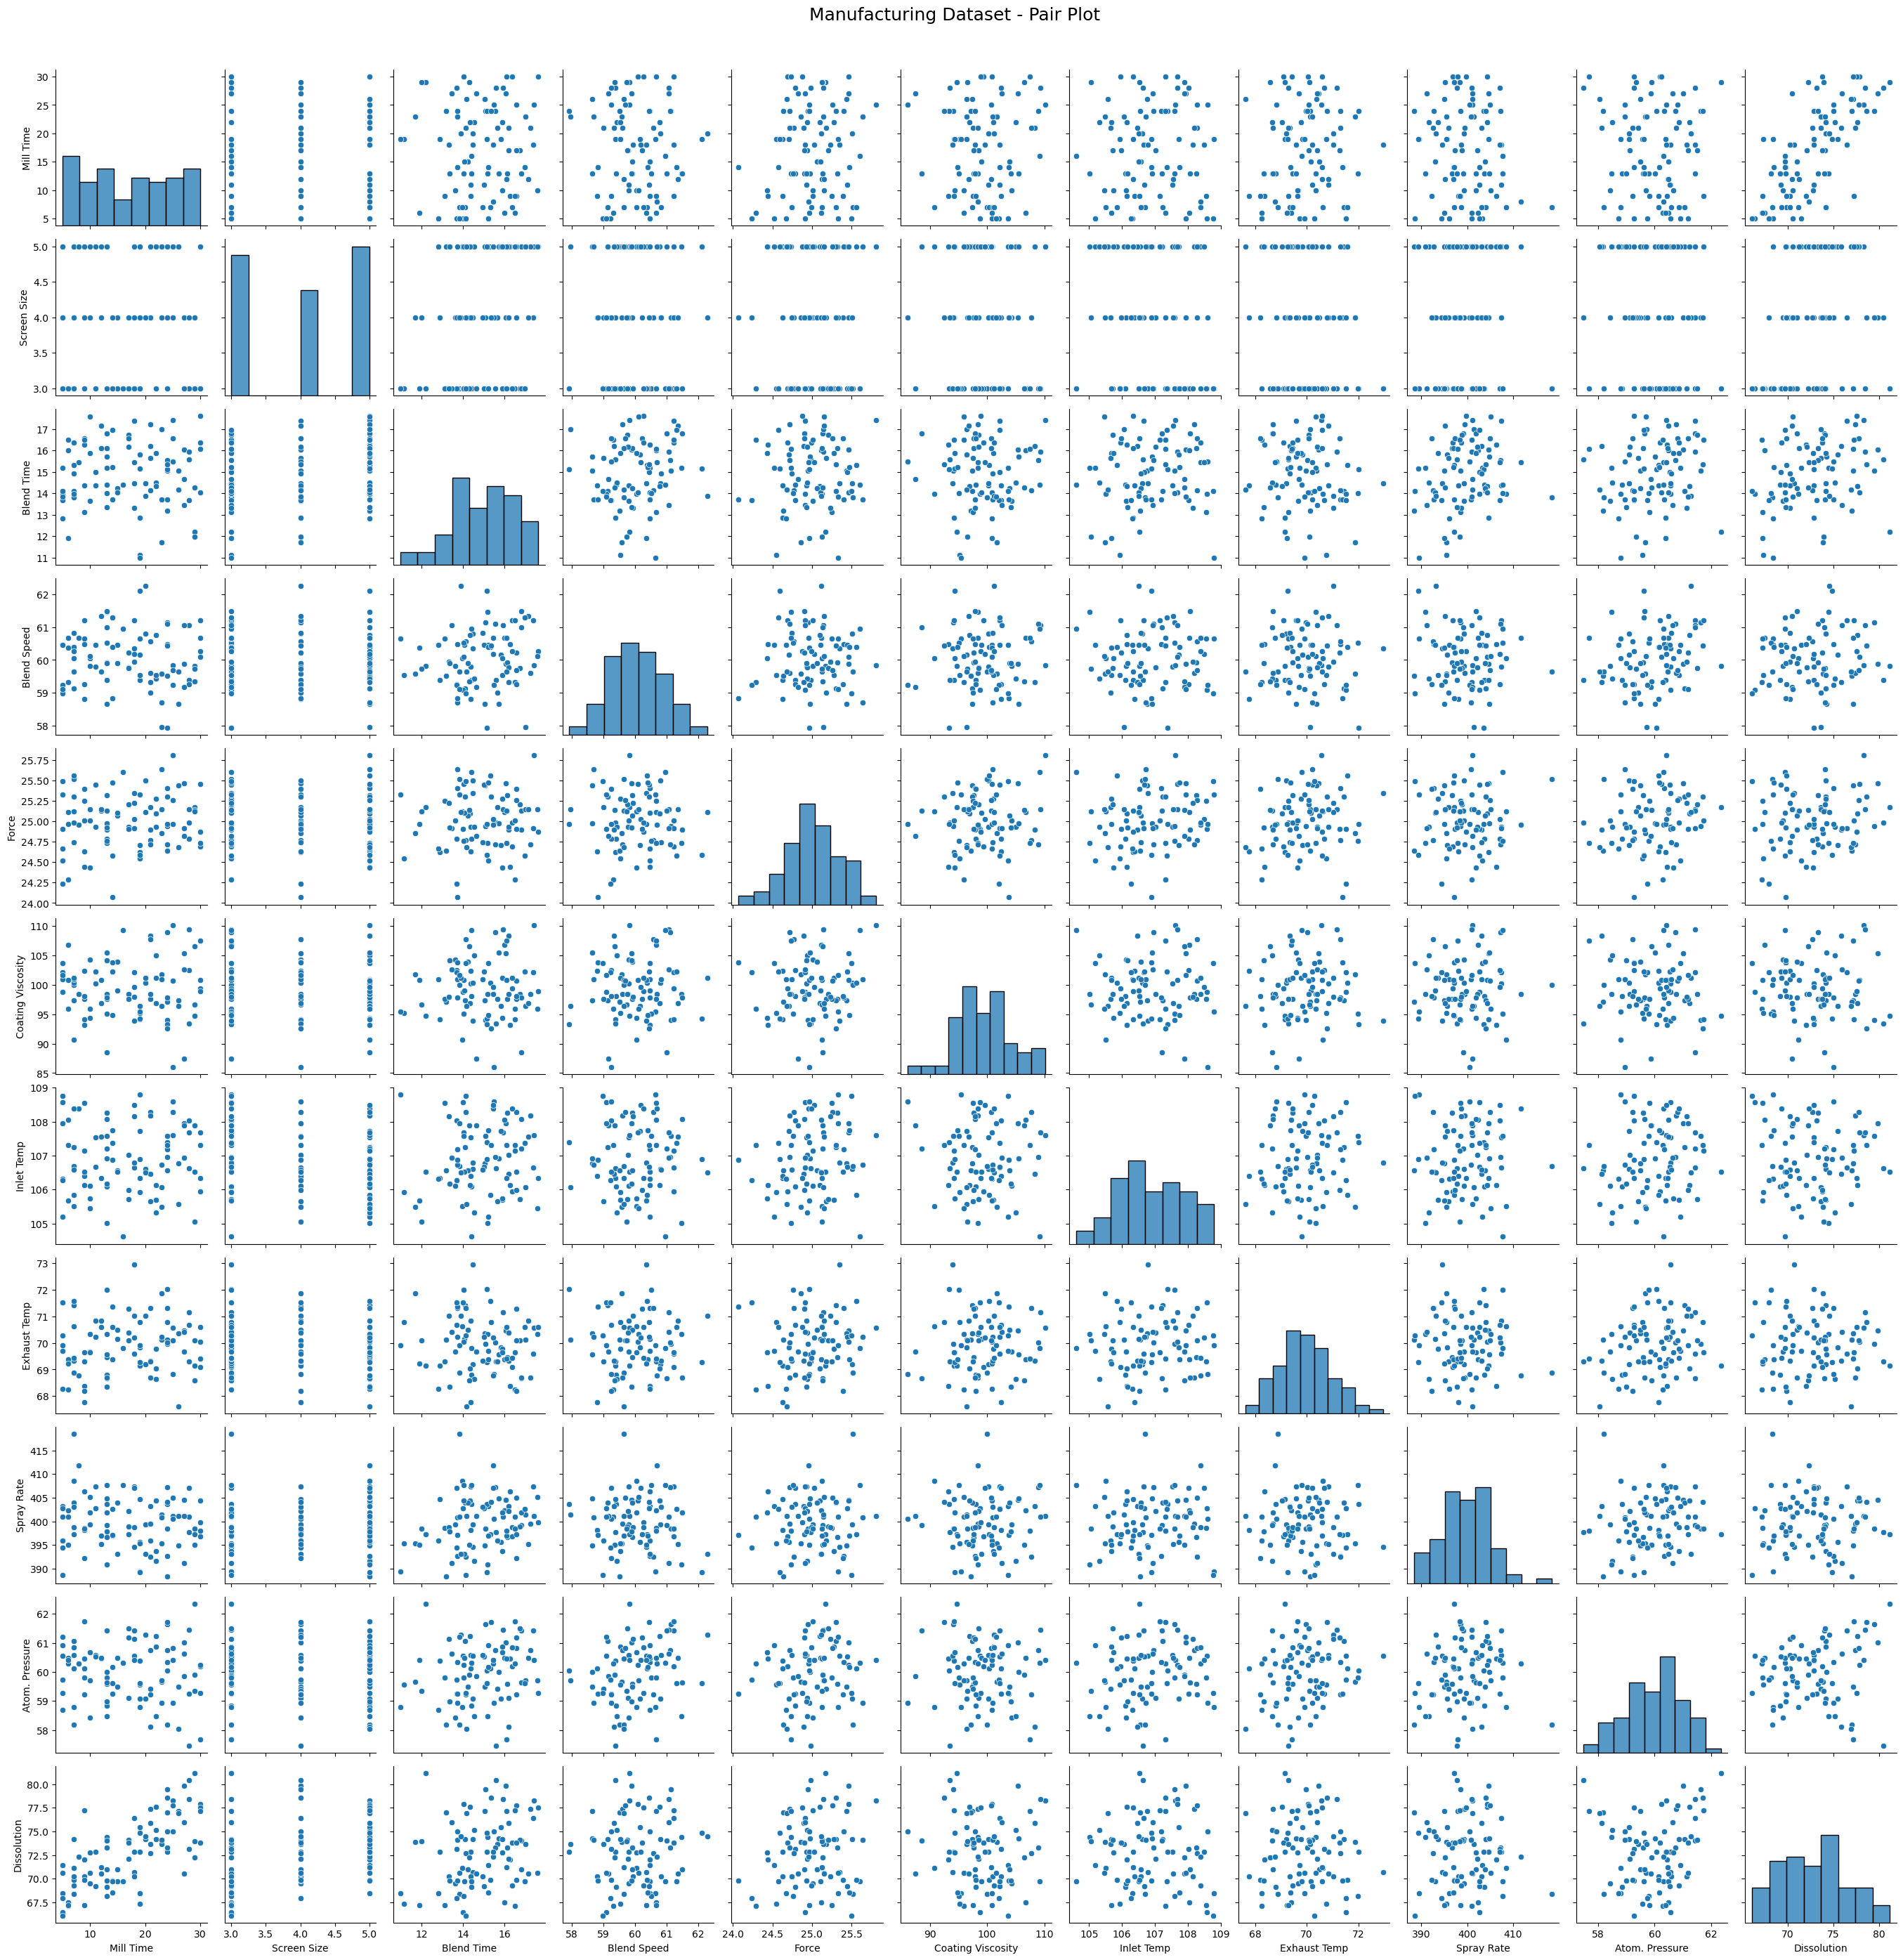

In [19]:
# read manufacturing data
df_manuf = pd.read_excel("./data_manufacturing.xlsx")

# filter the table to keep only float and integers
df_manuf_num = df_manuf.select_dtypes(include=['float64', 'int64'])

# create and save the pair plot
plt.figure()
manuf_pair = sns.pairplot(df_manuf_num)
manuf_pair.fig.suptitle("Manufacturing Dataset - Pair Plot", y=1.02, fontsize=18)
plt.savefig("manufacturing_pairplot.png", bbox_inches='tight')
plt.show()
plt.close('all')

### Pair Plot Observations (manufacturing dataset)

- From the diagonal histograms we can see that the distributions are mixed. Most parameters like blend time, blend speed and force show tight, bell-shaped normal distributions centered around their targeted machine setpoints. However parameters like screen size or mill time are not normally distributed, they appear multi-modal or discrete because they are fixed choices (e.g. screen time).
- In the scatter plots you can spot several isolated dots in variables like coating viscosity, atom. pressure or dissolution that are located far away from the main bulk of the data. This is likely due to manufacturing inconsistencies, raw material variations and sensor noise.
- There is clustering present, specifically for screen size and mill time. The data forms horizontal or vertical stripes, because these values only take specific, stepped values instead of a continuous range of values.

## Create correlation matrix (manufacturing dataset)

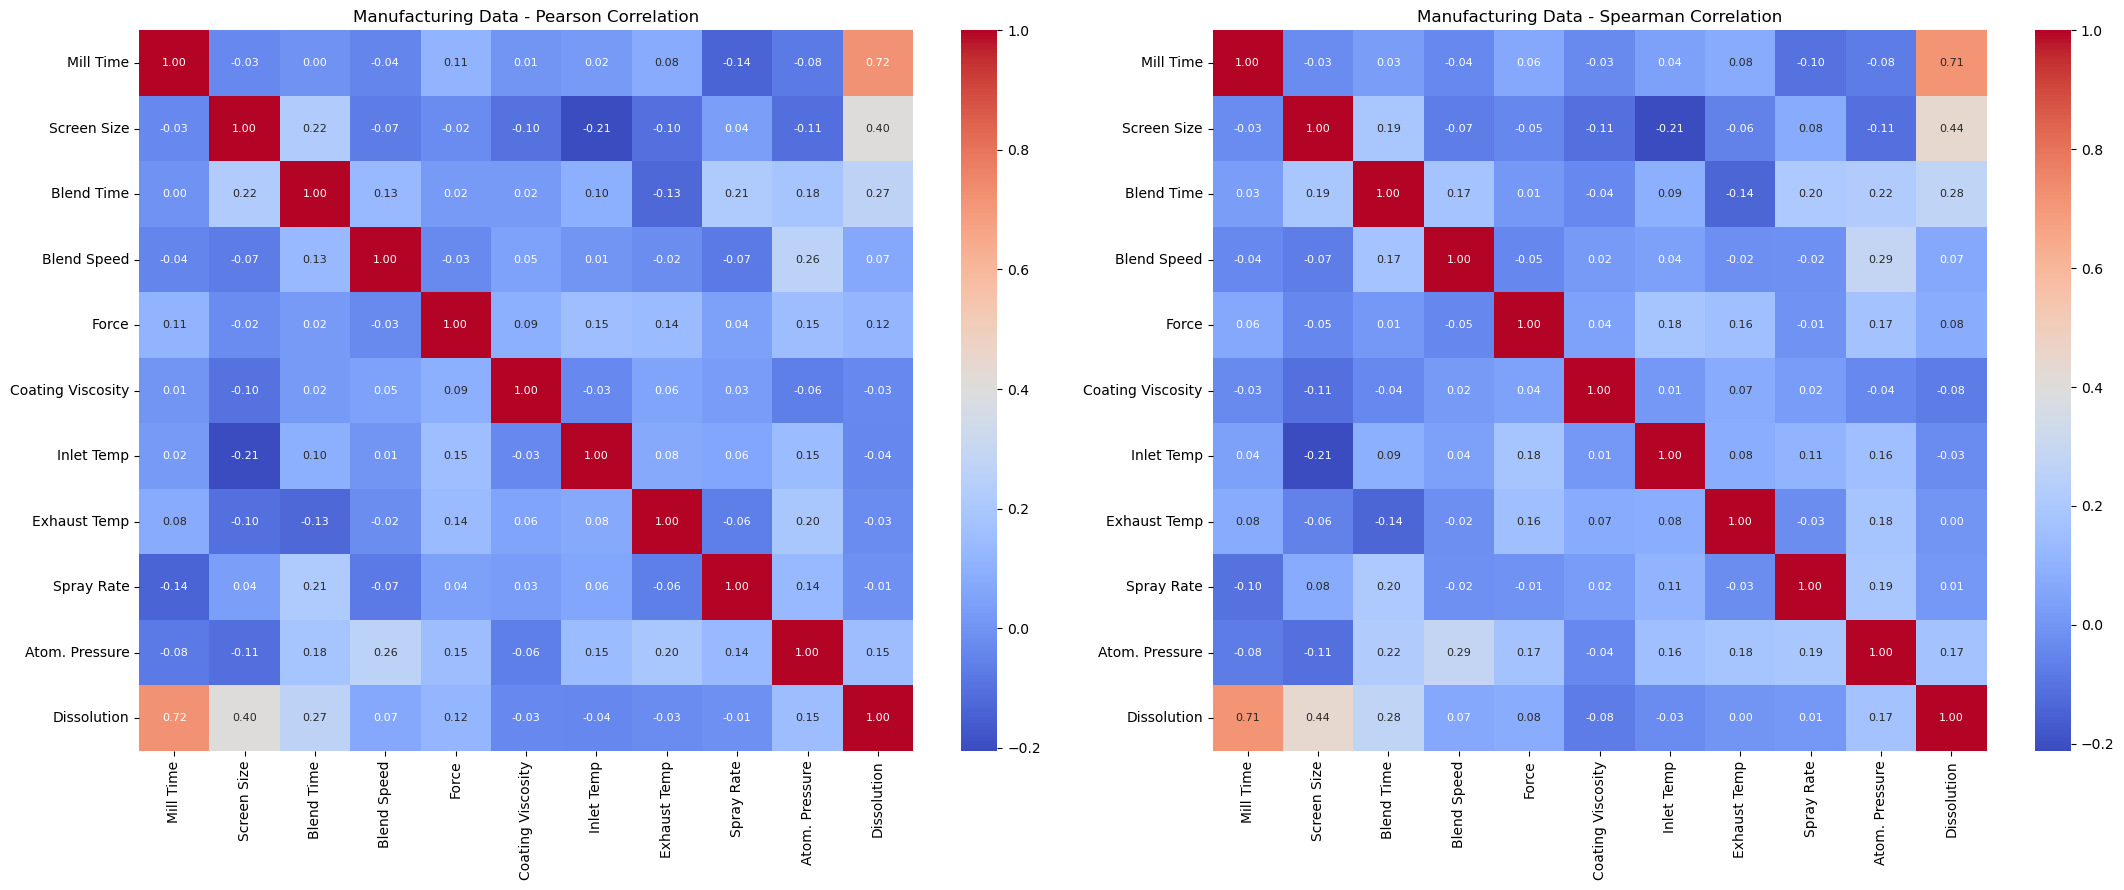

In [15]:
# calculate correlations
corr_manuf_pearson = df_manuf_num.corr(method='pearson')
corr_manuf_spearman = df_manuf_num.corr(method='spearman')

# create figure with 1 row and 2 columns for the heatmaps
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# draw the left pearson heatmap
sns.heatmap(corr_manuf_pearson, annot=True, cmap='coolwarm', ax=axes[0], fmt=".2f", annot_kws={"size": 8})
axes[0].set_title('Manufacturing Data - Pearson Correlation')

# draw the right spearman heatmap
sns.heatmap(corr_manuf_spearman, annot=True, cmap='coolwarm', ax=axes[1], fmt=".2f", annot_kws={"size": 8})
axes[1].set_title('Manufacturing Data - Spearman Correlation')

# tight layout and save the image
plt.tight_layout()
plt.savefig("manufacturing_heatmaps.png")
plt.show()
plt.close('all')

### Correlation Matrix Observations (manufacturing dataset)

- Most variables are independent and thus not correlated as they are indepedently set machine parameters. Correlations of screen size, blend time and mill time with the target dissolution are weak to moderate.
- There are also some other weaker correlated parameters that are around or below $0.2$.
- For evaluating relationships involving discrete variables (e.g. screen size) the Spearman correlation is superior since it evaluates the rank order.